In [1]:
import pandas as pd              # Para análisis de datos
import numpy as np               # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para gráficos
import seaborn as sns            # Para gráficos bonitos

Este programa es una extension del programa de RK4UnaVariable para resolver sistemas de ecuaciones del estilo 
$$
\left\{
\begin{array}{l}
\frac{dx_1(t)}{dt} = f(t,x_1,x_2) \\\\
\frac{dx_2(t)}{dt} = g(t,x_1,x_2)
\end{array}
\right\}.
$$


Ahora llamamos $\vec{x}(t) = (x_1(t),x_2(t))$ y $\vec{k_i} = (k_i^{(1)},k_i^{(2)})$ y $\vec{f}(t,x_1,x_2) = (f(t,x_1,x_2),g(t,x_1,x_2))$. Entonces RK4 para el sistema de dos ecuaciones es: 

$\vec{x}(t_{k+1}) = \vec{x}(t_{k}) + \frac{h}{6}(\vec{k_1} + 2\vec{k_2} + 2\vec{k_3} + \vec{k_4})$

con:

$\vec{k_1} = \vec{f}(t_k,\vec{x}(t_k))$ 

$\vec{k_2} = \vec{f}(t_k + \frac{h}{2},\vec{x}(t_k) + \frac{h}{2}\vec{k_1})$

$\vec{k_3} = f(t_k + \frac{h}{2},\vec{x}(t_k) + \frac{h}{2}\vec{k_2})$

$\vec{k_4} = f(t_k + h,\vec{x}(t_k) + h\vec{k_3})$

Para realizar la funcion RK4 necesitamos conocer $\vec{f}(t,x_1,x_2)$, $t_0$, $t_1$, $\vec{x}(t_0) = \vec{x_0}$ y el tamaño del paso $h$. La implementacion de lo anterior es:

In [2]:
def rk4_system(vecfunc,t0,t1,X0,h):
    # vecfunc = vector de funciones
    # t0 = valor incial
    # t1 = limite superior de t
    # X0 = X(t0), donde X(t) es el vector de variables X = (x1,x2,x3...)
    # h = tamaño del paso

    N = int((t1-t0) / h) # Numero de subdivisiones

    X = np.zeros((2,N+1)) # Pongo N+1 ya que luego en el bucle for llegamos hasta k+1 y si no se sale de rango
                            # Matriz vacia para almacenar los puntos de X. Hay tantas filas como variables.
    
    for k in range (0,2,1):
        X[k][0] = X0[k]
    
    t = np.zeros(N+1)
    t[0] = t0 

    for k in range (0,N,1):
        k11 = vecfunc[0](t[k],X[0][k],X[1][k]) # Escribo X[:][k] para escoger todas las filas pero solo una columna
        k12 = vecfunc[1](t[k],X[0][k],X[1][k])
        k21 = vecfunc[0](t[k] + h/2,X[0][k] + (h/2)*k11,X[1][k] + (h/2)*k12)
        k22 = vecfunc[1](t[k] + h/2,X[0][k] + (h/2)*k11,X[1][k] + (h/2)*k12)  
        k31 = vecfunc[0](t[k] + h/2,X[0][k] + (h/2)*k21,X[1][k] + (h/2)*k22)
        k32 = vecfunc[1](t[k] + h/2,X[0][k] + (h/2)*k21,X[1][k] + (h/2)*k22)
        k41 = vecfunc[0](t[k] + h,X[0][k] + h*k31,X[1][k] + h*k32)
        k42 = vecfunc[1](t[k] + h,X[0][k] + h*k31,X[1][k] + h*k32)
        X[0][k+1] = X[0][k] + (h/6)*(k11 + 2*k21 + 2*k31 + k41)
        X[1][k+1] = X[1][k] + (h/6)*(k12 + 2*k22 + 2*k32 + k42)
        t[k+1] = t[0] + (k+1) * h  # Efectivamente para k = N-1 recuperamos t1 = t0 + h*N

    return t,X

El programa principal (problema a resolver) es el siguiente. 

$$
\left\{
\begin{array}{l}
I_1' = f(t,I_1,I_2) = -4I_1 + 3I_2 + 6 \\\\
I_2' = g(t,I_1,I_2) = -2.4I_1 + 1.6I_2 + 3.6
\end{array}
\right\}.
$$

con $I_1(0) = 0$ y $I_2(0) = 0$.

In [3]:
def i1prime(t,i1,i2):
    valor = -4*i1 + 3*i2 + 6
    return valor

def i2prime(t,i1,i2):
    valor = -2.4*i1 + 1.6*i2 + 3.6
    return valor

t0 = 0
t1 = 2
X0 = (0,0) # = (i1(0),i2(0)) : Valores iniciales de i1 e i2
h = 0.1
vF = (i1prime,i2prime)

t,X = rk4_system(vF,t0,t1,X0,h) # Sol numerica 

Las soluciones exactas son 

$I_1(t) = -3.375\,e^{-2t} + 1.875\,e^{-0.4t} + 1.5 $

$I_2(t) = -2.25\,e^{-2t} + 2.25\,e^{-0.4t}$

In [4]:
def i1_exact(t):
    valor = -3.375*(np.e**(-2*t)) + 1.875*(np.e**(-0.4*t)) + 1.5
    return valor

def i2_exact(t):
    valor = -2.25*(np.e**(-2*t)) + 2.25*(np.e**(-0.4*t))
    return valor

La comprobacion grafica es la siguiente.

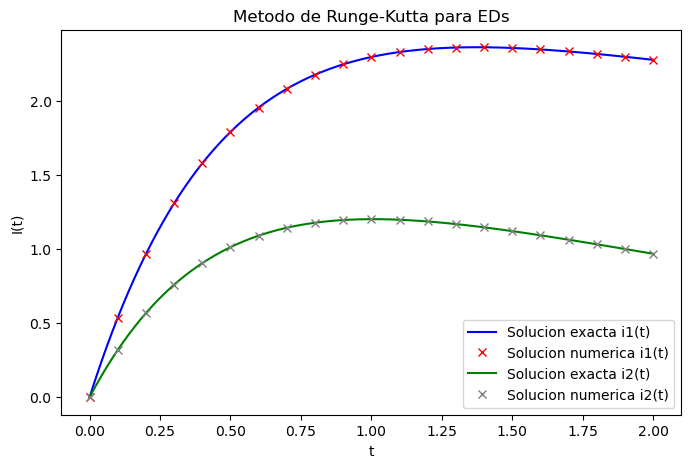

In [5]:
t_vals = np.linspace(t0, t1, 500) 
X_vals = np.array([i1_exact(t_vals),i2_exact(t_vals)])

plt.figure(figsize=(8, 5))
plt.plot(t_vals, X_vals[0][:], label='Solucion exacta i1(t)', color='blue')
plt.plot(t, X[0][:], 'x',label='Solucion numerica i1(t)', color='red')
plt.plot(t_vals, X_vals[1][:], label='Solucion exacta i2(t)', color='green')
plt.plot(t, X[1][:], 'x',label='Solucion numerica i2(t)', color='grey')
plt.title('Metodo de Runge-Kutta para EDs')
plt.xlabel('t')
plt.ylabel('I(t)')
plt.legend()
plt.grid(False)
plt.show()